# Decision Trees and Pruning

Decision Trees are powerful models used for classification and regression. They split data into subsets based on feature values, creating a tree-like structure. However, fully grown trees can overfit the training data. **Pruning** helps reduce complexity and improve generalization.


## How Decision Trees Work

Decision Trees split nodes based on impurity measures such as **Gini Index** or **Entropy**.

### Formulas:
- **Gini Index**:
\[
Gini = 1 - \sum_{i=1}^{C} p_i^2
\]

- **Entropy**:
\[
Entropy = - \sum_{i=1}^{C} p_i \log_2(p_i)
\]

Where \(p_i\) is the proportion of class \(i\) in the node.


## Pruning in Decision Trees

Pruning reduces the size of a decision tree by removing branches that have little predictive power.

### Types of Pruning:
1. **Pre-Pruning (Early Stopping)**: Stop tree growth early using constraints like `max_depth`, `min_samples_split`.
2. **Post-Pruning (Cost Complexity Pruning)**: Grow the full tree, then prune back.

### Cost Complexity Formula:
\[
R_\alpha(T) = R(T) + \alpha |T|
\]
Where:
- \(R(T)\): Misclassification error of tree \(T\)
- \(|T|\): Number of leaves
- \(\alpha\): Complexity parameter


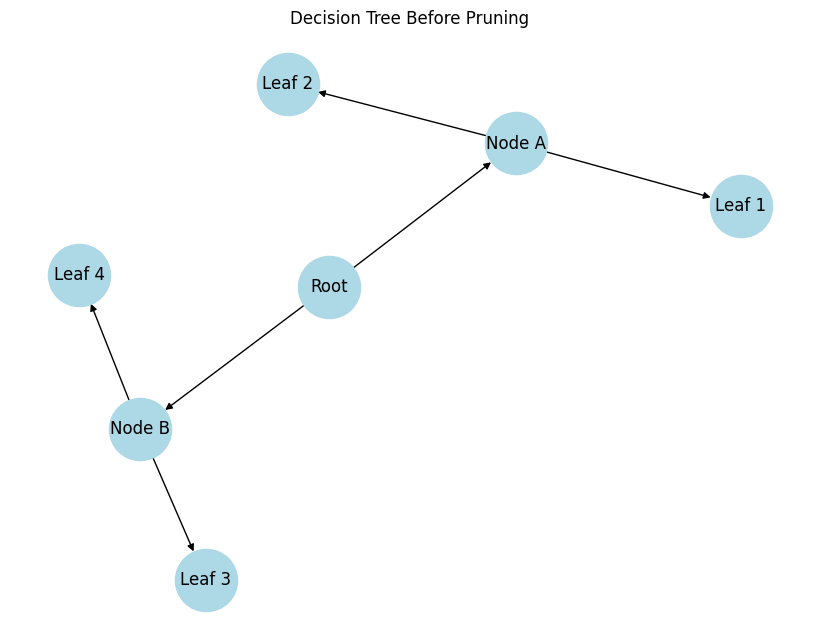

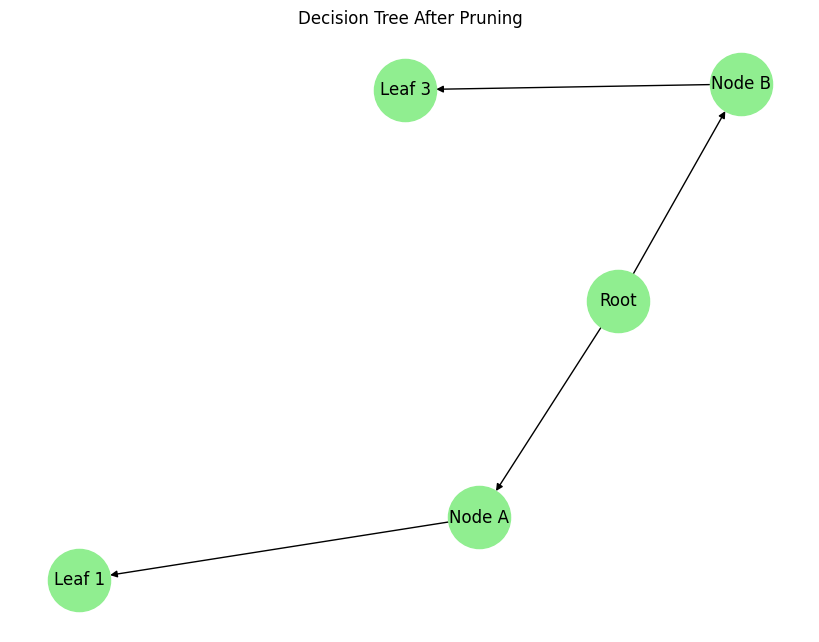

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

# Simple tree before pruning
G = nx.DiGraph()
G.add_edges_from([("Root", "Node A"), ("Root", "Node B"), ("Node A", "Leaf 1"), ("Node A", "Leaf 2"), ("Node B", "Leaf 3"), ("Node B", "Leaf 4")])

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=12)
plt.title('Decision Tree Before Pruning')
plt.show()

# After pruning
G_pruned = nx.DiGraph()
G_pruned.add_edges_from([("Root", "Node A"), ("Root", "Node B"), ("Node A", "Leaf 1"), ("Node B", "Leaf 3")])

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_pruned)
nx.draw(G_pruned, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=12)
plt.title('Decision Tree After Pruning')
plt.show()


In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Load dataset
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train full tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
print('Accuracy (Full Tree):', clf.score(X_test, y_test))

# Pruned tree using cost complexity pruning
clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.02)
clf_pruned.fit(X_train, y_train)
print('Accuracy (Pruned Tree):', clf_pruned.score(X_test, y_test))


Accuracy (Full Tree): 1.0
Accuracy (Pruned Tree): 1.0


## Conclusion

Pruning helps prevent overfitting by simplifying the tree structure. It improves generalization and makes the model more interpretable.
